# Homework14

Pre-Trained Transformer Models and Embeddings

## Goals

- Practice setting up classification and clustering modeling task from scratch
- Experiment with pre-trained transformer models for embedding and feature extraction
- Get more familiar with the `argmax()` and `pairwise_distance()` functions

### Setup

Run the following 2 cells to import all necessary libraries and helpers for this homework

In [1]:
!wget -q https://github.com/PSAM-5020-2026S-A/Homework14/raw/refs/heads/main/Homework04_utils.py
!wget -qO- https://github.com/PSAM-5020-2026S-A/5020-utils/releases/latest/download/forest-tree.tar.gz | tar xz
!wget -qO- https://github.com/PSAM-5020-2026S-A/5020-utils/releases/latest/download/flowers102.tar.gz | tar xz

In [85]:
import pandas as pd
import torch
from PIL import Image
import numpy as np

from numpy import argsort
from os import listdir
from PIL import Image as PImage

from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics.pairwise import euclidean_distances

from torch import nn, Tensor, no_grad
from torch import float32 as t_float32, uint8 as t_uint8

from torchvision.models import resnet50, ResNet50_Weights
from torchvision.transforms import v2

from transformers import CLIPModel, CLIPProcessor

from Homework04_utils import Homework04Utils

# Pre-Trained Models for Feature Extraction

We're going to repeat the very first image classification exercise we did in [`HW04`](https://github.com/PSAM-5020-2026S-A/Homework04), but this time we'll use a pre-trained model (and `PCA`) to help us extract features from our images.

The overall flow for doing this will be:
- Open images
- Get embeddings
- Get main principal component
- Plot and create a model
- Evaluate

In [3]:
# Location of train/test files
TRAIN_PATH = "data/image/forest-tree/train"
TEST_PATH = "data/image/forest-tree/test"

# List comprehension for getting all of the filenames that end in "jpg" inside the train directory
train_files = sorted([f for f in listdir(TRAIN_PATH) if f.endswith("jpg")])
test_files = sorted([f for f in listdir(TEST_PATH) if f.endswith("jpg")])

In [4]:
# Initialize an image feature extraction model
model_name = "openai/clip-vit-large-patch14"
preprocessor = CLIPProcessor.from_pretrained(model_name)
model = CLIPModel.from_pretrained(model_name).to("cuda")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Extract Features

So many features !!

Here we are going to leverage the full power of multi-dimensional tensors and parallelism to preprocess and run feature extraction on all $30$ train images and then all $150$ test images ***AT ONCE***.

If we just do something like:
`preprocessor(image_list)`

we'll get a list of tensors that we can pass to the model directly like this:
`model(tensor_list)`

and get a list of embeddings.

The result of running these commands on the training dataset will be a list with $30$ embeddings, where each embedding itself is a list of $768$ values.

In [5]:
# Get list of images
train_imgs = [PImage.open(f"{TRAIN_PATH}/{fname}") for fname in train_files]

# Get list of tensors
train_t = preprocessor(images=train_imgs, return_tensors="pt").to("cuda")

# Get list of embeddings
with no_grad():
  train_embs = model.get_image_features(**train_t).pooler_output.cpu()

display(train_embs.shape)

torch.Size([30, 768])

In [6]:
# TODO: repeat for test images
test_imgs = [PImage.open(f"{TEST_PATH}/{fname}") for fname in test_files]
test_t = preprocessor(images=test_imgs, return_tensors="pt").to("cuda")

with no_grad():
  test_embs = model.get_image_features(**test_t).pooler_output.cpu()

display(test_embs.shape)

torch.Size([150, 768])

## One Feature To Rule Them All

We now have $768$ features for each of our images, but since we're building a model manually with some `if/else` statements like in `HW04`, we need to combine all of our features into a few numbers we can plot and extract information from.

`PCA`, FTW.

Let's create a `PCA` model to extract a single feature from each image.

In [12]:
# TODO: create PCA
#       fit with the training data
#       transform train/test embeddings
from sklearn.decomposition import PCA
pca = PCA(n_components=1)
train_pca = pca.fit(train_embs)
train_pcs = pca.transform(train_embs)
test_pcs = pca.transform(test_embs)

In [19]:
lis = zip(train_files, *train_pcs)
for i in lis:
    print(i)

('florist-02.jpg', np.float64(-9.604420696328813), np.float64(-9.535037233359523), np.float64(-9.154966105460005), np.float64(-9.658652642374442), np.float64(-7.023213357602165), np.float64(-8.57508460616216), np.float64(-9.832433875426567), np.float64(-10.102138964009269), np.float64(-9.236606756845738), np.float64(-7.495574867333819), np.float64(6.095407092360832), np.float64(6.366517564207605), np.float64(4.893879133690793), np.float64(7.026966984791834), np.float64(5.337095726452212), np.float64(5.999376725952958), np.float64(5.8510878830938875), np.float64(6.21085602845403), np.float64(5.876408401099594), np.float64(6.077996039521208), np.float64(3.1827507811229214), np.float64(2.755293560371605), np.float64(3.9957005292931305), np.float64(3.842136334730295), np.float64(2.929397793441007), np.float64(3.441368289194531), np.float64(2.39592601233808), np.float64(2.6207945841247042), np.float64(2.5415724051082442), np.float64(2.7775972355530216))


## Visualize / Explore

This next cell is very similar to what we did in `HW04`.

It's the cell that separates a single value from each image and passes off the result to a function that will plot feature versus class label.

It assumes that the train and test principal components are in `train_pcs` and `test_pcs`, respectively.

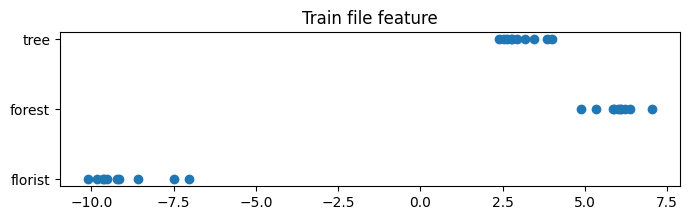

In [34]:
# list to keep info about image files
train_info = []

# iterate through pcs and filenames
for pcs,fname in zip(train_pcs, train_files):
  # TODO: get value of interest
  val = pcs[0]


  # store the info using the format specified above
  train_info.append([ val, fname ])

# plot the (val, filename) pairs
Homework04Utils.plot_labels_vals(train_info, "Train file feature")

## Create Model

Use the extracted value to create a classifier.

The class labels it has to return are: `"florist", "forest", "tree"`.

In [20]:
# TODO: return a label based on embeddings and/or pcs
def awesome_classifier(pcs):
  # TODO: fill out this function !!!
  if pcs[0] < 0:
    return "florist"
  elif pcs[0] > 0 and pcs[0] < 4:
    return "forest"
  else:
    return "tree"

In [27]:
clip_classifier = awesome_classifier

### Run on `train` and `test` data and check accuracy

This cell is already filled out, we just have to run it to get the accuracy values for our model.

In [28]:
# lists to keep info about predictions
train_predictions = []
test_predictions = []

# iterate through train data
for pcs,fname in zip(train_pcs, train_files):
  prediction = clip_classifier(pcs)
  train_predictions.append([ prediction, fname ])

print("Train Accuracy")
print("  ", Homework04Utils.classification_accuracy(train_predictions))


# iterate through test data
for pcs,fname in zip(test_pcs, test_files):
  prediction = clip_classifier(pcs)
  test_predictions.append([ prediction, fname ])

print("\nTest Accuracy")
print("  ", Homework04Utils.classification_accuracy(test_predictions))

Train Accuracy
   {'florist': 1.0, 'forest': 0.0, 'tree': 0.0, 'overall': 0.33333}

Test Accuracy
   {'florist': 1.0, 'forest': 0.0, 'tree': 0.04, 'overall': 0.34667}


# One-Shot Classification

## Intro

We're going to leverage the general knowledge and patterns learned by pre-trained deep learning models to create a one-shot classifier model.

One-shot classifiers are models that learn how to describe/detect objects by just looking at one example from each class.

The overall flow for doing this using image embeddings can be something like:
- extract embeddings for all images in our dataset
- training: for each class, average a small number of embeddings to create class embeddings
- these embeddings now represent information about the classes we're trying to identify
- predicting: find the closest class embedding to each image embedding in the dataset

This is similar to one of the examples in our [Week 14](https://github.com/PSAM-5020-2026S-A/WK14) notebook where we used words to classify images.

## The Data

We're going to classify the [Oxford Flowers Dataset](https://www.robots.ox.ac.uk/~vgg/data/flowers/). This is a dataset made up of images of flowers and their names.

All of the images we're going to be working with should have been downloaded by the first cell, into separate `train` and `test` subdirectories inside `./data/image/flowers102/`.

The images all have the same (or similar) height, but very different widths. Depending on the architecture/model that we choose to use for  embedding, this might be something we have to standardize. Transformer architectures and their preprocessors will automatically deal with these differences, where CNN models are a bit more strict.

Let's start by defining a function that helps parse the classification label from file names or paths.

In [36]:
def filepath_to_label(filepath):
  return filepath.split("/")[-1].split("_")[-1].split(".")[0]

## The Model

Now we have to define an embedding model, and (probably) a pre-processing strategy.

What wee need here is a pre-trained model that is able to turn images of various sizes into feature lists of fixed-length.

Our [Week 14](https://github.com/PSAM-5020-2026S-A/WK14) notebook has a couple of examples of how to use `ResNet`, `CLIP` and `SigLIP` models to do this, but there are other options that could be used. Since we're not doing any text processing, any kind of deep learning visual model can (theoretically) be used.

Some other examples: [Nomic Vision](https://huggingface.co/nomic-ai/nomic-embed-vision-v1.5), [EfficientNet](https://pytorch.org/hub/nvidia_deeplearningexamples_efficientnet/), [ViT](https://huggingface.co/google/vit-base-patch16-224-in21k), [DINOv3](https://huggingface.co/facebook/dinov3-vitl16-pretrain-lvd1689m), etc.

In [40]:
# TODO: define model and pre-processing routine/function/strategy for images
model = resnet50(weights=ResNet50_Weights.DEFAULT)
model.eval()
preprocessor = v2.Compose([
    v2.Resize((232, 232)),
    v2.CenterCrop(224),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## Train Data

Now we process the train data. Fun.

There are many ways to do this, but one possible strategy is to go through all of the files inside the `./data/image/flowers102/train` directory and append each image's label and embedding to separate lists, called `train_labels` and `train_embeddings`.

Then, create a `DataFrame` using the embeddings and add the labels to the same `DataFrame`.

Depending on the model chosen, this can take a few minutes.

In [47]:
# TODO: extract labels and embeddings for each image in the training dataset

TRAIN_DIR = "./data/image/flowers102/train"

train_fnames = sorted([f for f in listdir(TRAIN_DIR) if f.endswith("jpg")])

train_labels = []
train_embeddings = []

for fname in train_fnames:
  # TODO: replace this with code
    label = filepath_to_label(fname)

    image = Image.open(f"{TRAIN_DIR}/{fname}").convert("RGB")
    tensor = preprocessor(image).unsqueeze(0)
    with torch.no_grad():
        embedding = model(tensor).squeeze().numpy()

    train_labels.append(label)
    train_embeddings.append(embedding)


# TODO: combine the lists into a DataFrame
train_df = pd.DataFrame({
    "label": train_labels,
    "embedding": train_embeddings
})

print(train_df.head())

             label                                          embedding
0     garden-phlox  [-0.5484711, 0.5634763, -0.14978336, -0.080167...
1         bee-balm  [-0.41362, 0.15790233, -0.07708983, 0.16629672...
2       wallflower  [-0.37448296, 0.7585402, -0.01204635, -0.17725...
3      thorn-apple  [-0.1707934, -0.45173213, 0.24605185, 0.170719...
4  mexican-petunia  [-0.6160493, 0.20712478, -0.01740286, -0.05833...


In [55]:
print(len(train_df))
print(len(train_df["embedding"][0]))
unique_classes = train_df["label"].unique()
print(len(unique_classes))

408
1000
102


### Train Data Questions

<span style="color:hotpink;">
How many images are in the training dataset ?<br>
How many <em>"features"</em> ?<br>
How many unique classes do we have for this data ?
</span>

1. there is 408 images in the dataset
2. And the dataset has to features, label and embedding
3. So there is 102 unqiue classes correspond to individual flower label

## Test Data

Repeat the above process for the files inside the `./data/image/flowers102/test` directory: append each image's label and embedding to separate lists, called `test_labels` and `test_embeddings`.

Since we won't do any other kind of processing on this data, it's not as important to combine the labels and embeddings into a `DataFrame`.

And again, this can take a few minutes.

In [56]:
# TODO: Repeat label and embedding extraction for all images in the test dataset
TEST_DIR = "./data/image/flowers102/test"

test_fnames = sorted([f for f in listdir(TEST_DIR) if f.endswith("jpg")])

test_labels = []
test_embeddings = []

for fname in test_fnames:
  # TODO: replace this with code
    label = filepath_to_label(fname)
    image = Image.open(f"{TEST_DIR}/{fname}").convert("RGB")
    tensor = preprocessor(image).unsqueeze(0)
    with torch.no_grad():
        embedding = model(tensor).squeeze().numpy()
    test_labels.append(label)
    test_embeddings.append(embedding)

#DataFrame
test_df = pd.DataFrame({
    "label": test_labels,
    "embedding": test_embeddings
})

print(test_df.head())

               label                                          embedding
0     passion-flower  [-0.6681013, 0.2107107, -0.04282806, -0.003255...
1        desert-rose  [-0.5411309, 0.40896899, -0.2929443, 0.0126095...
2       bearded-iris  [0.45437527, 1.459949, -0.07646185, -0.4621565...
3           camellia  [-0.48111784, 0.3919204, 0.1923201, -0.0473890...
4  purple-coneflower  [-0.20992139, 0.41159028, 0.023989793, -0.1382...


In [57]:
print(len(test_df))
print(len(test_df["embedding"][0]))
unique_classes = test_df["label"].unique()
print(len(unique_classes))

5416
1000
102


### Test Data Questions

<span style="color:hotpink;">
How many images are in the test dataset ?<br>
Anything odd or unusual about this ?<br>
Is the test dataset balanced ?<br>
Does it matter ?
</span>

1. There is 5416 images in the dataset
2. which is drastically larger then the train dataset
3. Apparently is about 1:10 ratio which is not very balanced
4. I think it matter, because model will have less to learn and is harder to find pattern, and with a huge test dataset to pouring into the model, the model might get overwhelmed and have poor performance

## Train the model

This is the unconventional part. We don't need to train any models, but use the already-trained one to derive some information about our training data that can then be used to make new predictions.

There are different ways to do this, but a recommended strategy here could be:
- get a list of unique labels in our dataset
- iterate over the labels, filter the `DataFrame` by label and compute an average embedding for all images of each label
- these are now class embeddings, as they hold aggregate information about multiple instances of each class
- we should end up with as many class embeddings as there are unique labels in the dataset

In [93]:
# TODO: create class embeddings by averaging embeddings for all images of each label
unique_classes = train_df["label"].unique()
class_embedding = {}
for cls in unique_classes:
    class_embedding[cls] = train_df[train_df["label"] == cls]["embedding"].mean() # it will create a boolean mask to filter the dataframe

for cls, embedding in class_embedding.items():
    print(f"Class: {cls}, Embedding: {embedding[0]}")


Class: garden-phlox, Embedding: -0.3767828941345215
Class: bee-balm, Embedding: -0.2453320324420929
Class: wallflower, Embedding: -0.5775694251060486
Class: thorn-apple, Embedding: -0.4540358781814575
Class: mexican-petunia, Embedding: -0.4645136594772339
Class: snapdragon, Embedding: -0.5276715755462646
Class: osteospermum, Embedding: -0.17615634202957153
Class: sunflower, Embedding: -0.30633509159088135
Class: camellia, Embedding: -0.6681076288223267
Class: ruby-lipped-cattleya, Embedding: -0.4937279224395752
Class: blanket-flower, Embedding: -0.26812830567359924
Class: marigold, Embedding: -0.5533002018928528
Class: silverbush, Embedding: -0.6091671586036682
Class: great-masterwort, Embedding: -0.35067299008369446
Class: globe-thistle, Embedding: 0.05232707038521767
Class: canna-lily, Embedding: -0.5010177493095398
Class: hibiscus, Embedding: -0.521645188331604
Class: common-dandelion, Embedding: -0.29050686955451965
Class: love-in-the-mist, Embedding: 0.051679063588380814
Class: co

## Predict and Evaluate

We have class embeddings, and we have instance embeddings from all images in the test dataset.

We can use the `euclidean_distances()` function to calculate pairwise distances between each image and each class embedding.

Then, we'll go through each image and get the index of the class embedding that is closest to its image embedding.

We can create a `predictions` list to compare to the `test_labels` list we extracted above.

In [94]:
# TODO: use euclidean_distances() and argsort() to determine the closest class for each image

class_names   = list(class_embedding.keys())
class_vectors = np.stack(list(class_embedding.values()))
test_vectors  = np.stack(test_df["embedding"].values)

distances        = euclidean_distances(test_vectors, class_vectors)
test_preds = [class_names[i] for i in distances.argsort(axis=1)[:, 0]]
test_labels = test_df["label"].tolist()

In [95]:
print(classification_report(test_labels, test_preds))

                           precision    recall  f1-score   support

         alpine-sea-holly       0.87      0.69      0.77        39
                anthurium       0.86      0.63      0.73        60
                artichoke       0.90      1.00      0.94        60
                   azalea       0.20      0.43      0.28        60
                ball-moss       0.88      0.50      0.64        42
           balloon-flower       0.15      0.09      0.11        45
           barbeton-daisy       0.55      0.62      0.58        60
             bearded-iris       0.26      0.16      0.20        50
                 bee-balm       0.67      0.55      0.61        60
         bird-of-paradise       0.92      0.80      0.86        60
       bishop-of-llandaff       0.70      0.85      0.77        60
         black-eyed-susan       0.40      0.66      0.50        50
          blackberry-lily       0.81      0.77      0.79        44
           blanket-flower       0.39      0.62      0.48     

### Interpretation

<span style="color:hotpink;">
So... What happened ?<br>
What are some advantages and disadvantages of using this strategy for classification ?
</span>

The result came out about 56 percent accuracy, which is not as bad as I imagine, but with a 50 percent accuracy is not a good model to use. About the ability of classification model, I think the model is intuitive when you think about is just comparing to objects by their similarity and group it, but the disadvantages is the process of creating the class and sorting it then classifiying it, also I think is not complex neural network that can spot very detail patterns. But overall I think is very sufficient way to do machine learning, and It probabaly can solve 50 percent of your problems.